In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import psycopg2 as ps
import networkx as nx
import random
import numpy as np

In [46]:
patriotic_alternative_nodes = pd.read_csv("Patriotic_Alternative_Nodes.csv")
Patriotic_Alternative = pd.read_csv("Patriotic_Alternative_Edge.csv")

In [47]:
middle_node_ids = patriotic_alternative_nodes[
    (patriotic_alternative_nodes['lat'] == 53.666612) & 
    (patriotic_alternative_nodes['lng'] == -13.222169)
]['Id'].tolist()

trans_nodes = patriotic_alternative_nodes[
    (patriotic_alternative_nodes['lat'] == 53.562336) & 
    (patriotic_alternative_nodes['lng'] == -20.691347)
]['Id'].tolist()

patriotic_alternative_nodes = patriotic_alternative_nodes[
    
    ~((patriotic_alternative_nodes['lat'] == 53.666612) & (patriotic_alternative_nodes['lng'] == -13.222169)) &
    ~((patriotic_alternative_nodes['lat'] == 53.562336) & (patriotic_alternative_nodes['lng'] == -20.691347))
]['Id'].tolist()

In [48]:
patriotic_alternative_nodes['layer'] = 'trans'
patriotic_alternative_nodes.loc[patriotic_alternative_nodes['Id'].isin(middle_node_ids), 'layer'] = 'middle'
patriotic_alternative_nodes.loc[patriotic_alternative_nodes['Id'].isin(trans_nodes), 'layer'] = 'trans'
patriotic_alternative_nodes.loc[patriotic_alternative_nodes['Id'].isin(regional_nodes), 'layer'] = 'regional'


In [50]:
G = nx.Graph()

# Add nodes with attributes
for _, row in patriotic_alternative_nodes.iterrows():
    G.add_node(row['Id'], layer=row['layer'], lat=row['lat'], lng=row['lng'], label=row['Label'])

# Add edges
for _, row in Patriotic_Alternative.iterrows():
    G.add_edge(row['Source'], row['Target'])

In [51]:
middle_layer_nodes = [node for node, data in G.nodes(data=True) if data.get('layer') == 'middle']
all_nodes = [node for node, data in G.nodes(data=True)]

In [52]:
initial_largest_component = max(nx.connected_components(G), key=len)
initial_component_size = len(initial_largest_component)
initial_avg_path_length = nx.average_shortest_path_length(G.subgraph(initial_largest_component))
initial_global_efficiency = nx.global_efficiency(G)

In [31]:
fragmentation_results_middle = []
G_middle = G.copy()

for node in middle_layer_nodes[:10]:
    G_middle.remove_node(node)
    
    largest_component = max(nx.connected_components(G_middle), key=len)
    component_size = len(largest_component)
    avg_path_length = nx.average_shortest_path_length(G_middle.subgraph(largest_component))
    diameter = nx.diameter(G_middle.subgraph(largest_component))
    
    laplacian_matrix = nx.laplacian_matrix(G_middle.subgraph(largest_component)).todense()
    eigenvalues = np.linalg.eigvalsh(laplacian_matrix)
    algebraic_connectivity = sorted(eigenvalues)[1] if len(eigenvalues) > 1 else 0
    
    fragmentation_results_middle.append({
        'step': len(fragmentation_results_middle) + 1,
        'largest_component_size': component_size,
        'average_path_length': avg_path_length,
        'diameter': diameter,
        'algebraic_connectivity': algebraic_connectivity
    })

df_fragmentation_middle = pd.DataFrame(fragmentation_results_middle)

In [53]:
all_random_results = []

for i in range(10):
    G_random = G.copy()
    random_nodes = random.sample(list(G_random.nodes()), 10)
    
    for j, node in enumerate(random_nodes, 1):
        G_random.remove_node(node)
        
        largest_component = max(nx.connected_components(G_random), key=len)
        component_size = len(largest_component)
        avg_path_length = nx.average_shortest_path_length(G_random.subgraph(largest_component))
        diameter = nx.diameter(G_random.subgraph(largest_component))
        
        laplacian_matrix = nx.laplacian_matrix(G_random.subgraph(largest_component)).todense()
        eigenvalues = np.linalg.eigvalsh(laplacian_matrix)
        algebraic_connectivity = sorted(eigenvalues)[1] if len(eigenvalues) > 1 else 0
        
        all_random_results.append({
            'iteration': i,
            'step': j,
            'largest_component_size': component_size,
            'average_path_length': avg_path_length,
            'diameter': diameter,
            'algebraic_connectivity': algebraic_connectivity
        })

df_fragmentation_random = pd.DataFrame(all_random_results)


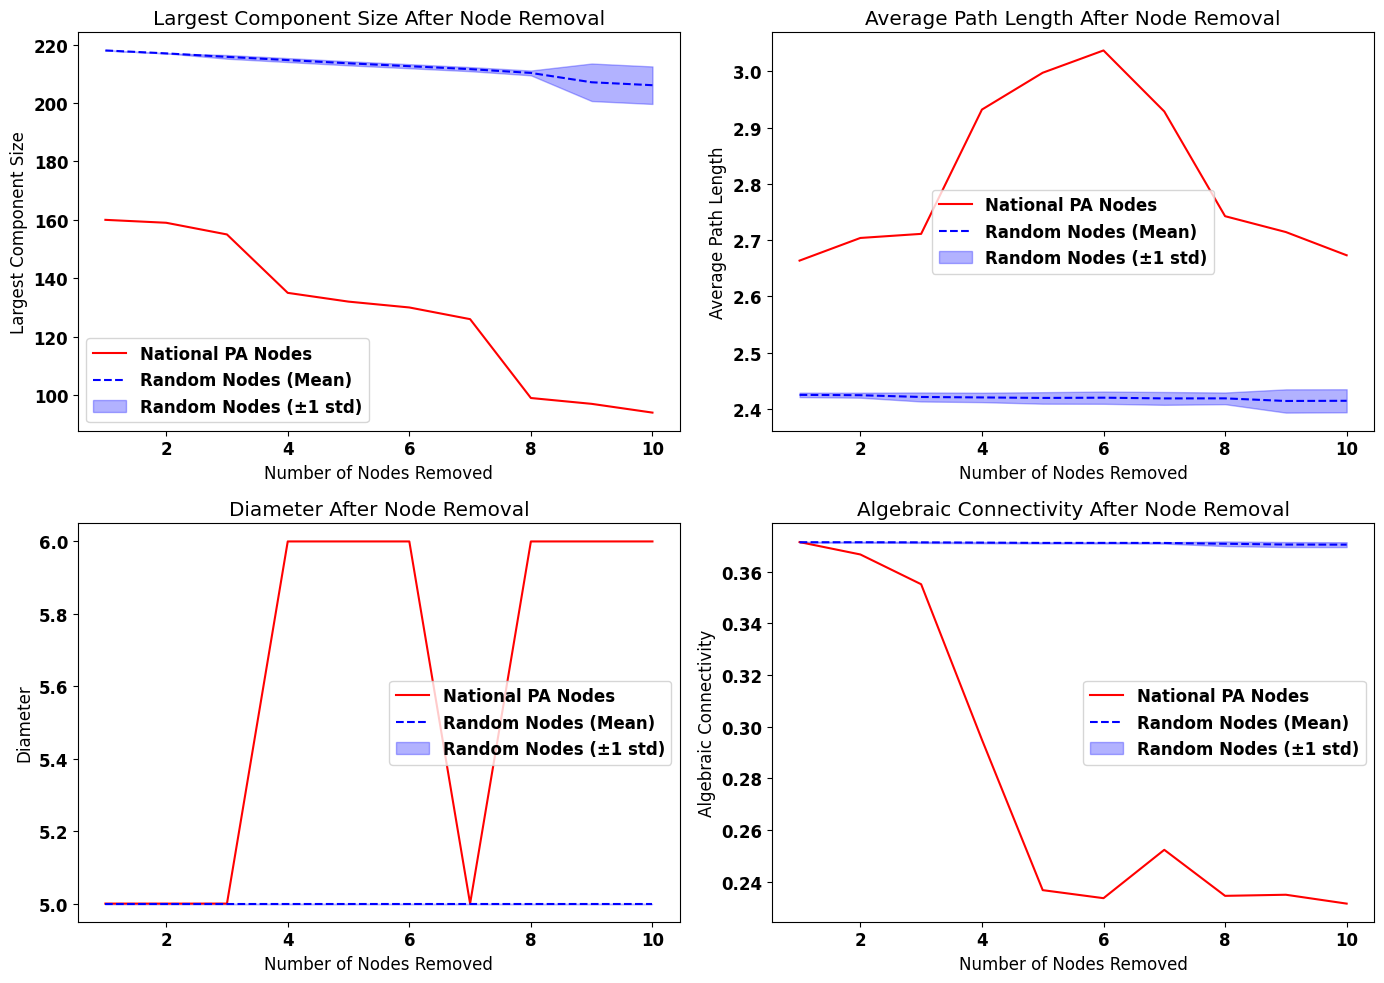

In [54]:
# Create visualization
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['largest_component_size', 'average_path_length', 'diameter', 'algebraic_connectivity']
titles = ['Largest Component Size', 'Average Path Length', 'Diameter', 'Algebraic Connectivity']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = divmod(idx, 2)  # Calculate row and column index for 2x2 layout
    
    # Plot middle nodes line
    axs[row, col].plot(df_fragmentation_middle['step'], df_fragmentation_middle[metric], 'r-', label='National PA Nodes')
    
    # Plot random nodes mean and distribution
    mean = df_fragmentation_random.groupby('step')[metric].mean()
    std = df_fragmentation_random.groupby('step')[metric].std()
    
    axs[row, col].plot(mean.index, mean.values, 'b--', label='Random Nodes (Mean)')
    axs[row, col].fill_between(mean.index, 
                               mean.values - std.values,
                               mean.values + std.values,
                               alpha=0.3, color='b',
                               label='Random Nodes (±1 std)')
    
    axs[row, col].set_title(f'{title} After Node Removal')
    axs[row, col].set_xlabel('Number of Nodes Removed')
    axs[row, col].set_ylabel(title)
    axs[row, col].legend()

plt.tight_layout()
plt.show()

## City Platform Analysis

In [55]:
## Platform distribution of city nodes
city_platform_distribution = patriotic_alternative_nodes[patriotic_alternative_nodes['layer'] == 'regional']['SNS'].value_counts()

In [56]:
city_platform_distribution

SNS
TG         10
Odysee      4
Gab         4
YouTube     2
Name: count, dtype: int64

In [57]:
Patriotic_Alternative[Patriotic_Alternative['Target'].isin(regional_nodes)]['Source'].unique().tolist()

['TG__482',
 'TG__140',
 'TG__74',
 'TG__154',
 'TG__122',
 'TG__27',
 'Gab__18',
 'TG__240',
 'TG__404',
 'Gab__10',
 'TG__313',
 'TG__500',
 'TG__497',
 'TG__218',
 'TG__321',
 '4Chan__1',
 'TG__325',
 'TG__447',
 'TG__503',
 'Gab__31',
 'TG__158',
 'Gab__5',
 'Gab__411',
 'TG__84']

In [58]:
## Platform distribution of nodes targettign city nodes

target_platform_distribution = patriotic_alternative_nodes[patriotic_alternative_nodes['Id'].isin(Patriotic_Alternative[Patriotic_Alternative['Target'].isin(regional_nodes)]['Source'].unique().tolist())]['SNS'].value_counts()

In [59]:
platform_city = list(city_platform_distribution.index)
platform_target = list(target_platform_distribution.index)

In [60]:
platform_city = ['Telegram' if platform == 'TG' else platform for platform in platform_city]
platform_target = ['Telegram' if platform == 'TG' else platform for platform in platform_target]

# Combine platforms from both lists and create a unique color mapping
unique_platforms = list(set(platform_city + platform_target))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_platforms)))  # Use tab20 colormap for distinct colors

# Create a dictionary to map each unique platform to a color
color_mapping = dict(zip(unique_platforms, colors))

# Function to show absolute values in the pie chart
def absolute_value(val, values):
    a = int(round(val / 100. * sum(values)))
    return f'{a:,}'



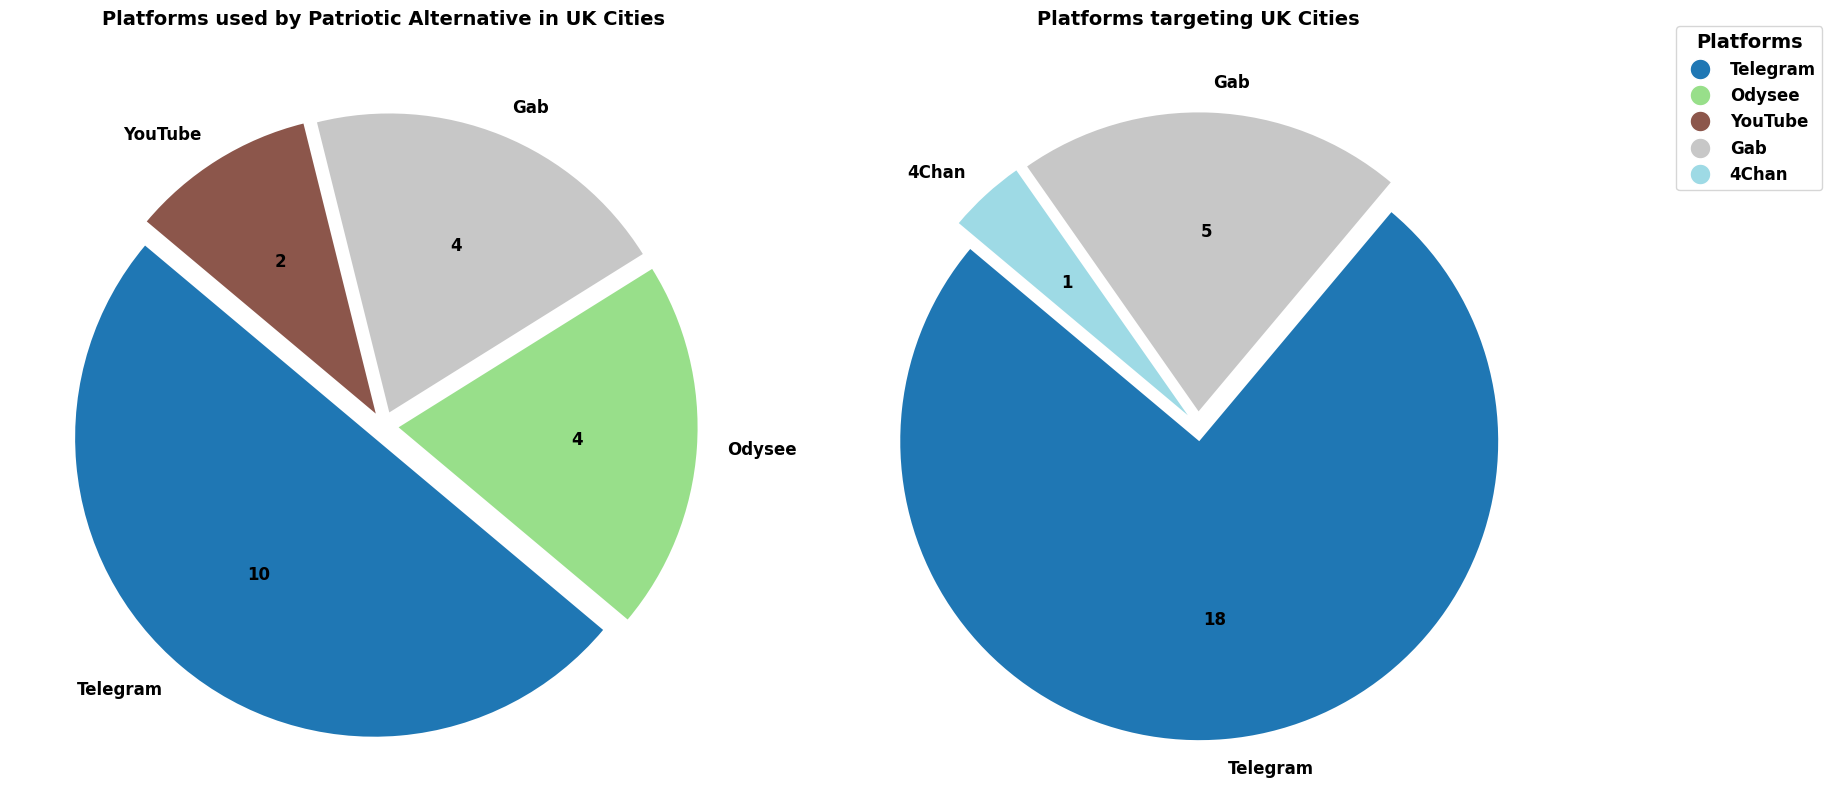

In [61]:
# Increase font sizes and make text bold
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot for City Nodes
ax1.pie(city_platform_distribution.values, labels=platform_city, 
        autopct=lambda val: absolute_value(val, city_platform_distribution.values),
        colors=[color_mapping[platform] for platform in platform_city], 
        startangle=140, shadow=False, explode=[0.05] * len(platform_city),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Platforms used by Patriotic Alternative in UK Cities', pad=20, fontsize=14, fontweight='bold')

# Plot for Nodes Targeting Cities
ax2.pie(target_platform_distribution.values, labels=platform_target, 
        autopct=lambda val: absolute_value(val, target_platform_distribution.values),
        colors=[color_mapping[platform] for platform in platform_target], 
        startangle=140, shadow=False, explode=[0.05] * len(platform_target),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Platforms targeting UK Cities', pad=20, fontsize=14, fontweight='bold')

# Create legend with larger size
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_mapping[platform], markersize=15)
                  for platform in unique_platforms]

# Position legend at top right with larger font
fig.legend(legend_handles, unique_platforms, 
          loc="upper right", 
          title="Platforms",
          bbox_to_anchor=(1.15, 1.0),
          fontsize=12,
          title_fontsize=14,
          prop={'weight': 'bold'})

# Adjust layout
plt.tight_layout()
plt.show()